# TS Lab 1

Requirements: 

In [21]:
# If needed:
# !pip -q install numpy pandas matplotlib statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. Dataset: small + interpretable
We’ll use a synthetic dataset so that we can see the components clearly.

Create a synthetic time series with components:

In [22]:
np.random.seed(7)

n = 500                      # 120 months = 10 years
t = np.arange(n)
trend = 0.05 * t
seasonality = 2.0 * np.sin(2 * np.pi * t / 12)   # yearly seasonality (period 12)
noise = np.random.normal(0, 0.8, size=n)

y = 10 + trend + seasonality + noise

ts = pd.Series(y, index=pd.period_range("2015-01", periods=n, freq="M").to_timestamp())
ts.head()


2015-01-01    11.352421
2015-02-01    10.677250
2015-03-01    11.858307
2015-04-01    12.476013
2015-05-01    11.300912
Freq: MS, dtype: float64

Plot and visually identify components:

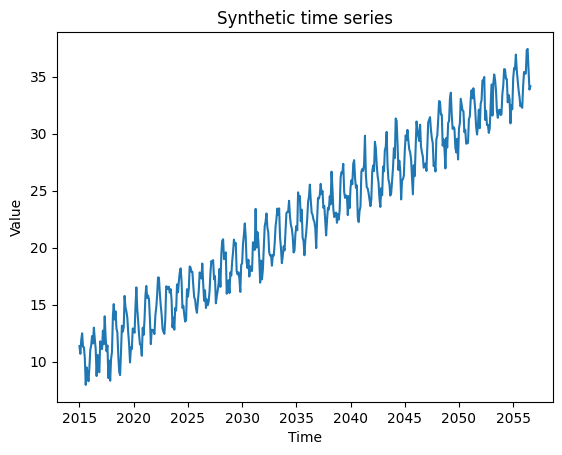

In [23]:
plt.figure()
plt.plot(ts)
plt.title("Synthetic time series")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


### Questions + short answers (my observations):

- Where do you see trend?
  - I see a clear upward drift over time, so the baseline level keeps increasing across the series.

- What suggests seasonality? What is the likely period?
  - The repeating wave pattern suggests seasonality. It seams like yearly seasonality, so a 12 month period.

- What part looks like noise?
  - The chart has noise all over it seams like, both in hte seasonality changes in scale but the space between is also a bit "noisy" or squiggly. 

- Create a series with no trend and no clear seasonality.
  - Done in the next code cell .

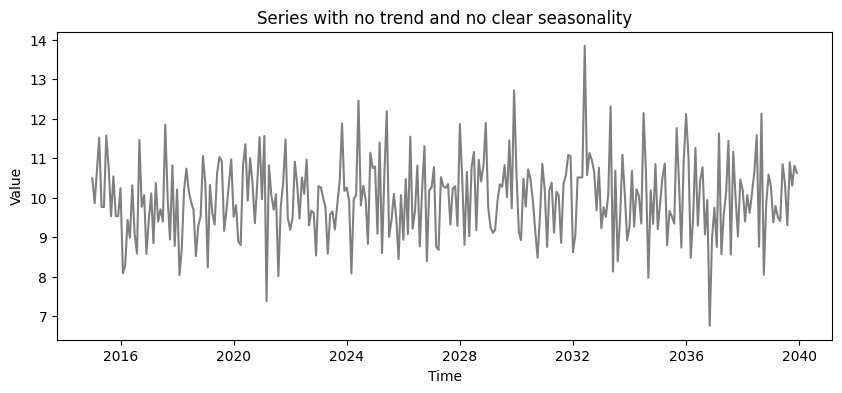

In [31]:
# Exercise: create a series with no trend and no clear seasonality
np.random.seed(42)
n2 = 300
white_noise = np.random.normal(loc=10, scale=1.0, size=n2)
ts_noise = pd.Series(
    white_noise,
    index=pd.period_range("2015-01", periods=n2, freq="M").to_timestamp()
 )

plt.figure(figsize=(10, 4))
plt.plot(ts_noise, color="gray")
plt.title("Series with no trend and no clear seasonality")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

### 2. Moving Average Smoothing

Implement moving average:

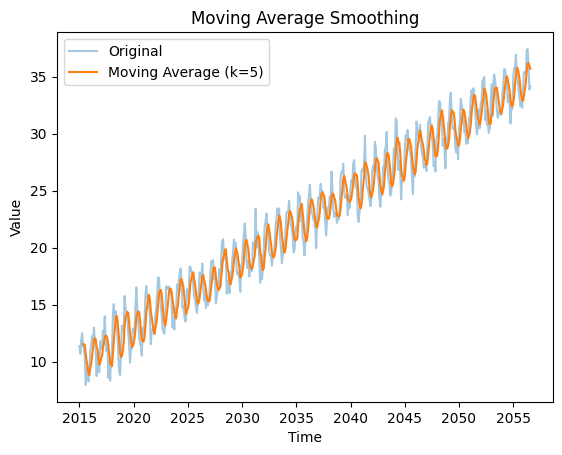

In [25]:
def moving_average(series, k):
    return series.rolling(window=k).mean()

k = 5
ma12 = moving_average(ts, k)

plt.figure()
plt.plot(ts, label="Original", alpha=0.4)
plt.plot(ma12, label=f"Moving Average (k={k})")
plt.title("Moving Average Smoothing")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


#### Exercises + answers:

- Try k=3, k=6, k=12, k=24.
  - Done in the next code cell with one combined comparison plot.

- Which k best reveals the trend? Which one hides seasonality too much?
  - In my run, k=6 gave a good balance for reveling the trend but also keeping the seasonality, if only trend i would say k=12.
  - k=24 looked very smooth and started hiding seasonality too much.

#### Questions:

- What happens when the window becomes very large?
  - The curve gets much smoother but reacts slowly and can miss shorter patterns and seasonality is not included anymore.

- Why do we lose some data at the beginning?
  - Rolling mean needs the previous k points, so the first k-1 values are undefined (NaN).

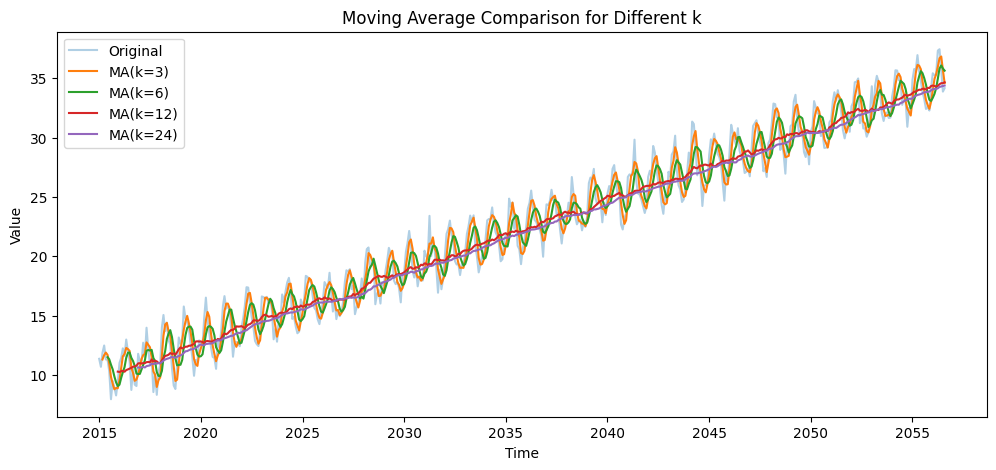

In [26]:
# Exercise: compare multiple moving-average windows
window_list = [3, 6, 12, 24]

plt.figure(figsize=(12, 5))
plt.plot(ts, alpha=0.35, label="Original")
for kk in window_list:
    ma_k = moving_average(ts, kk)
    plt.plot(ma_k, label=f"MA(k={kk})")

plt.title("Moving Average Comparison for Different k")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

### 3. Exponential Smoothing

Implement exponential smoothing from scratch:

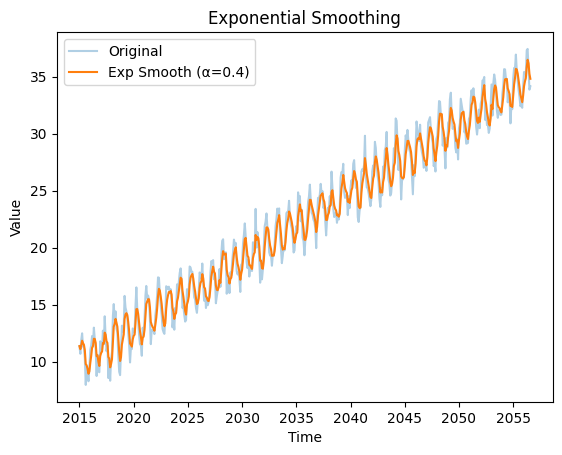

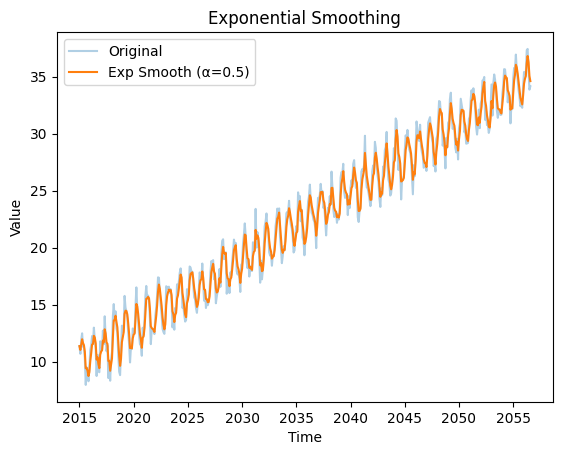

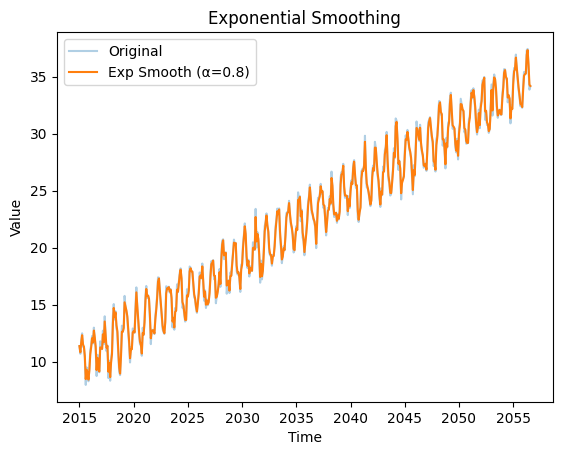

In [27]:
def exp_smooth(series, alpha):
    s = np.zeros(len(series))
    s[0] = series.iloc[0]
    for i in range(1, len(series)):
        s[i] = alpha * series.iloc[i] + (1 - alpha) * s[i-1]
    return pd.Series(s, index=series.index)

for alpha in [0.4, 0.5, 0.8]:
    sm = exp_smooth(ts, alpha)
    plt.figure()
    plt.plot(ts, alpha=0.35, label="Original")
    plt.plot(sm, label=f"Exp Smooth (α={alpha})")
    plt.title("Exponential Smoothing")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()


#### Questions + short answers:

- Why does larger α react faster?
  - Bigger alpha gives more weight to the newest point, so the smoothed line follows sudden changes faster.

- Why does smaller α look smoother?
  - Smaller alpha keeps more memory from earlier values, so random ups/downs are damped more.

### 4.Component patterns: “detect” trend/seasonality/noise

Detrend with moving average. Inspect residuals:

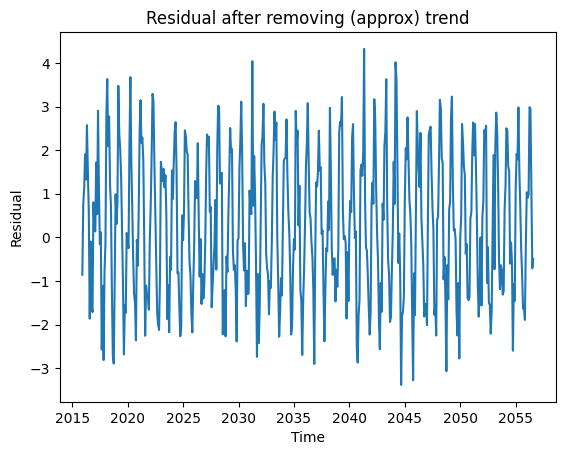

In [28]:
trend_est = moving_average(ts, 12)
residual = ts - trend_est

plt.figure()
plt.plot(residual)
plt.title("Residual after removing (approx) trend")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()


#### Questions:
Does the residual still show seasonality? What do you see?

#### Answer:
Residual still shows some seasonality in a wave-like pattern, so the 12-point moving average did not fully remove the seasonal component. There is also random noise left, which is expected.

### 5.An example of sudden changes
- Creates a time series with a sudden jump
- Shows lag of Moving Average (MA)
- Shows lag of Exponential Moving Average (EMA)
- Compares them clearly

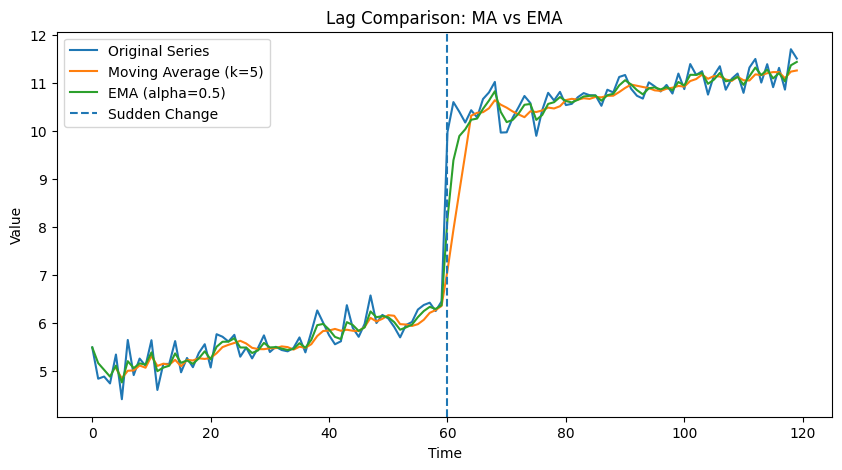

In [29]:

# -----------------------------
# 1) Create time series with sudden change
# -----------------------------
np.random.seed(1)

n = 120
t = np.arange(n)

# Base signal
y = 5 + 0.02*t + np.random.normal(0, 0.3, n)

#structural break
y[t >= 60] += 4


def moving_average(x, k):
    result = np.full_like(x, np.nan)
    for i in range(k-1, len(x)):
        result[i] = np.mean(x[i-k+1:i+1])
    return result


def ema(x, alpha):
    result = np.zeros_like(x)
    result[0] = x[0]
    for i in range(1, len(x)):
        result[i] = alpha*x[i] + (1-alpha)*result[i-1]
    return result


k = 5
alpha = 0.5

ma = moving_average(y, k)
ema_series = ema(y, alpha)

plt.figure(figsize=(10,5))
plt.plot(t, y, label="Original Series")
plt.plot(t, ma, label=f"Moving Average (k={k})")
plt.plot(t, ema_series, label=f"EMA (alpha={alpha})")
plt.axvline(60, linestyle="--", label="Sudden Change")
plt.title("Lag Comparison: MA vs EMA")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

Do MA and EMA behave differently for upward vs downward shocks? Implement your own code to examine their behaviour.

Yes. EMA usually reacts faster in both directions, while MA lags more because it averages a fixed window of past points.

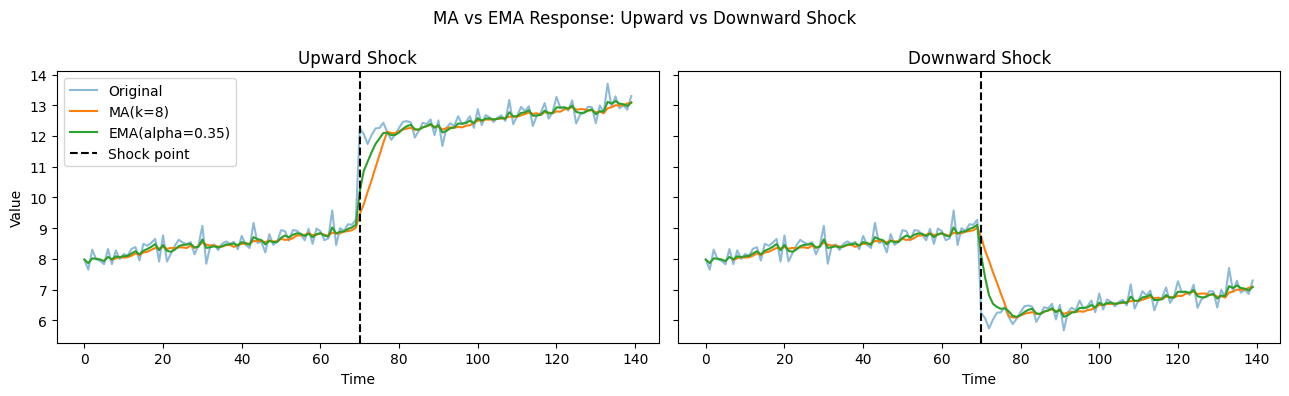

In [30]:
# Exercise: compare MA vs EMA for upward and downward shocks
np.random.seed(22)
n = 140
t = np.arange(n)

base = 8 + 0.015 * t + np.random.normal(0, 0.25, n)
up_shock = base.copy()
down_shock = base.copy()

# Upward and downward structural breaks
up_shock[t >= 70] += 3.0
down_shock[t >= 70] -= 3.0

def ma_np(x, k):
    out = np.full(len(x), np.nan)
    for i in range(k - 1, len(x)):
        out[i] = np.mean(x[i - k + 1:i + 1])
    return out

def ema_np(x, alpha):
    out = np.zeros(len(x))
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = alpha * x[i] + (1 - alpha) * out[i - 1]
    return out

k = 8
alpha = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, series, title in [
    (axes[0], up_shock, "Upward Shock"),
    (axes[1], down_shock, "Downward Shock")
]:
    ax.plot(t, series, label="Original", alpha=0.5)
    ax.plot(t, ma_np(series, k), label=f"MA(k={k})")
    ax.plot(t, ema_np(series, alpha), label=f"EMA(alpha={alpha})")
    ax.axvline(70, linestyle="--", color="black", label="Shock point")
    ax.set_title(title)
    ax.set_xlabel("Time")

axes[0].set_ylabel("Value")
axes[0].legend()
plt.suptitle("MA vs EMA Response: Upward vs Downward Shock")
plt.tight_layout()
plt.show()